# FAANG Stock Analysis — Winter 25/26 Assessment

## 📘 Introduction

This section introduces the Winter 25/26 assessment for the Computer Infrastructure module. It outlines the four core problems addressed in the notebook: data collection, visualisation, scripting, and automation. These tasks demonstrate proficiency in Python, reproducible analysis, and CI/CD workflows.

**Assessment Tasks:**

- Fetch hourly OHLCV data for FAANG tickers and save to timestamped CSV files in the `data` directory.
- Plot closing prices for each of the five stocks and save the plots as PNG files in the `plots` directory.
- Convert notebook logic into a CLI script.
- Automate execution via GitHub Actions.

## Import libraries

This section imports the necessary Python libraries for data manipulation, financial data retrieval, and plotting.

In [1]:
from pathlib import Path  # For cross-platform file and folder handling
from datetime import datetime, timezone  # For timestamped filenames
import pandas as pd # For data manipulation
import yfinance as yf  # Financial data API
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For enhanced plotting styles

### Helper Functions

This section defines reusable functions for verifying the environment, fetching hourly stock data, saving it to timestamped CSV files, and loading the most recent dataset. These utilities promote modularity, reproducibility, and clarity across both the notebook and CLI script.

- `verify_environment()` checks connectivity to the `yfinance` API by retrieving sample data for Apple (AAPL) and displaying a preview. It uses Python's built-in exception handling to catch and report errors.
- `fetch_hourly_history()` retrieves 5 days of hourly OHLCV data for a given ticker and formats it with a datetime index and ticker label.
- `save_hourly_data()` combines data from multiple tickers and saves it to a timestamped CSV in the `data/` folder. It includes logic to prevent overwriting unless explicitly allowed.
- `load_latest_data()` loads the most recent CSV file and splits it into individual DataFrames per ticker, with optional previews for inspection.

Relevant to: Problem 1 (Data Collection) and Problem 2 (Visualisation)

References:  
- [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)  
- [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)


In [2]:
# helper function to display dataframes in Jupyter notebooks
# this function checks yfinance connectivity by fetching sample data and optionally displaying it, 
# ensuring the environment is ready for data operations. 
# 📖 [Reference: yfinance Quickstart](https://pypi.org/project/yfinance/)
def verify_environment(show_preview=True):
    """Check yfinance connectivity and preview sample data."""
    try:
        df = yf.Ticker("AAPL").history(period="1d", interval="1h")
        print(f"✅ yfinance test passed — rows: {df.shape[0]}")
        if show_preview:
            display(df.head())
        return True
    except Exception as e:
        print(f"❌ yfinance test failed: {e}")
        return False

# helper function to fetch hourly data for a ticker
# this function retrieves 5 days of hourly OHLCV data for a given ticker and formats it for downstream analysis. 
# 📖 [Reference: yfinance.Ticker.history](https://github.com/ranaroussi/yfinance)
def fetch_hourly_history(ticker):
    """Fetch hourly OHLCV data for a single ticker."""
    try:
        df = yf.Ticker(ticker).history(period='5d', interval='1h')
        if df.empty:
            print(f"⚠️ No data for {ticker}")
            return None
        df['Ticker'] = ticker
        df.index.name = 'Date'
        return df
    except Exception as e:
        print(f"❌ Error fetching {ticker}: {e}")
        return None

# ticker for FAANG stocks
# this function aggregates hourly data for multiple tickers and saves it to a timestamped CSV, 
# supporting reproducibility and version control. 
# 📖 [Reference: pandas.DataFrame.to_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html)
def save_hourly_data(tickers, output_dir, overwrite=False):
    """Save combined hourly data for all tickers to a timestamped CSV."""
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 Saving to directory: {output_dir}")

    # Fetch data for each ticker
    dfs = []
    for t in tickers:
        df = fetch_hourly_history(t)
        if df is not None and not df.empty:
            print(f"✅ {t}: {len(df)} rows")
            dfs.append(df)
        else:
            print(f"⚠️ {t}: No valid data")

    # Exit if no valid data
    if not dfs:
        print("🚫 No valid data to save.")
        return None

    # Combine and save
    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"

    # Check for overwrite condition
    if path.exists():
        if overwrite:
            print(f"⚠️ Overwriting existing file: {path.name}")
        else:
            print(f"🛑 File already exists and overwrite=False: {path.name}")
            return None

    try:
        final_df.to_csv(path, index_label='Date')
        print(f"✅ Data saved to {path}")
        return str(path)
    except Exception as e:
        print(f"❌ Failed to save file: {e}")
        return None


# helper function to load the latest data file
# this function loads the most recent CSV file and splits it into individual DataFrames per ticker 
# for targeted plotting or analysis. 
# 📖 [Reference: pandas.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)
def load_latest_data(tickers, folder='data', show_preview=True):
    """Load the most recent CSV and split into ticker-specific DataFrames."""
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        raise FileNotFoundError("No CSV files found.")
    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}
    if show_preview:
        for t, subdf in data.items():
            print(f"{t}: {subdf.shape}")
            display(subdf.head())
    return data


### ⚙️ Setup & Configuration

This cell initialises the environment for data analysis and visualisation. It performs the following tasks:

- **Imports plotting libraries**:  
  - `matplotlib.pyplot` is used for creating static plots.  
  - `seaborn` enhances plot aesthetics and applies a clean grid-based style.

- **Defines global flags**:  
  - `SHOW_PREVIEW`: Controls whether data previews are displayed during execution.  
  - `OVERWRITE`: Prevents overwriting existing files unless explicitly allowed.

- **Sets up output directories**:  
  - `DATA_DIR`: Location where downloaded CSV files will be saved.  
  - `PLOTS_DIR`: Location where generated plots will be stored.  
  These paths are resolved to absolute locations and created if missing.

- **Applies consistent plotting style**:  
  - Sets default figure size for readability.  
  - Applies a white grid background using Seaborn for visual clarity.

This configuration ensures that all subsequent steps in the notebook produce consistent, well-formatted outputs and store results in an organised structure.

References:

- [matplotlib.pyplot documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.html)
- [Seaborn aesthetics tutorial](https://seaborn.pydata.org/tutorial/aesthetics.html)


In [3]:
# 🖼️ Plotting Configuration
# The following settings configure the visual style for plots.
# Note: matplotlib.pyplot and seaborn were imported in a previous cell.
# - matplotlib.pyplot is used for creating static line plots.
# - seaborn enhances plot aesthetics and applies a clean grid-based style.

# Global flags
SHOW_PREVIEW = True
OVERWRITE = False

# Output directories
DATA_DIR = Path("data").resolve()
PLOTS_DIR = Path("plots").resolve()

# Plotting style
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')


### ✅ Step 1 — Environment Check

This step validates that the system can successfully fetch financial data using the `yfinance` API — a critical prerequisite for Problem 1 (Data Collection). It performs the following actions:

- **Attempts to retrieve hourly data** for Apple (AAPL) to confirm API connectivity.
- **Displays a preview of the data** if `SHOW_PREVIEW` is enabled, allowing visual inspection of structure and content.
- **Uses Python's built-in exception handling** (`try-except`) to catch and report any errors, such as network issues or missing packages.

This approach ensures that the data collection process is robust and fails gracefully, aligning with best practices in infrastructure automation and referencing [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html).



In [4]:
# Run environment verification
verify_environment(SHOW_PREVIEW)


✅ yfinance test passed — rows: 7


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-11-14 09:30:00-05:00,271.049988,273.890015,269.600006,273.759186,10617822,0.0,0.0
2025-11-14 10:30:00-05:00,273.769989,274.649994,273.200012,274.649994,3569903,0.0,0.0
2025-11-14 11:30:00-05:00,274.644989,275.920013,273.549988,275.704987,4251993,0.0,0.0
2025-11-14 12:30:00-05:00,275.709991,275.958313,274.230011,274.584991,1963757,0.0,0.0
2025-11-14 13:30:00-05:00,274.570007,274.760010,273.839996,273.959991,1593851,0.0,0.0


True

### 📥 Step 2 — Problem 1: Fetch & Save FAANG Data

In this step, we create a function called get_data(). Think of this function as your data collector: it goes online, grabs the latest hourly stock information for the FAANG companies, and saves it neatly into a folder so you can use it later.

- FAANG tickers:
 - Facebook → META
 - Apple → AAPL
 - Amazon → AMZN
 - Netflix → NFLX
 - Google → GOOG

- **Data collected:** OHLCV (Open, High, Low, Close, Volume) prices for the last 5 days, at hourly intervals.
- **Storage:** The data is saved as a .csv file inside a folder called data/.
- **File naming:** Each file gets a unique timestamp (YYYYMMDD-HHmmss.csv) so you can tell when it was created.
- **Automation:** If the data/ folder doesn’t exist yet, the function will create it automatically.

This step is important because it ensures you always have a fresh dataset to work with in later problems (like plotting and analysis).

Relevant to: **Problem 1 (Data Collection)**

References:

- [yfinance Documentation](https://pypi.org/project/yfinance/)
- [pandas.DataFrame.to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html)

In [5]:
def get_data():
    tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
    output_dir = Path("data")
    save_hourly_data(tickers, output_dir)   # uses helper
    print("✅ Data fetched and saved.")

# Call the function
get_data()


📁 Saving to directory: data
✅ META: 35 rows
✅ AAPL: 35 rows
✅ AMZN: 35 rows
✅ NFLX: 35 rows
✅ GOOG: 35 rows
✅ Data saved to data\20251116-133857.csv
✅ Data fetched and saved.


### 📂 Step 3 — Load & Diagnose Data

In this step, we load the most recent CSV file from the `data/` folder. The file is then split into separate DataFrames for each FAANG ticker, all stored together in a dictionary called `data`.

To make sure the dataset is usable, we check each ticker’s DataFrame to confirm:
- The ticker is included in the file.
- Its DataFrame contains rows (not empty).

⚠️ **Important Clarification:**  
The `"Close"` column here represents the **hourly closing price** at the end of each trading interval, not the single consolidated daily close. The `yfinance` API only provides hourly data up to the most recent trading day. This means:
- On weekdays when markets are open, the dataset includes intraday hourly closes.  
- On weekends or holidays, no new hourly data is available, so the latest file will stop at the final close of the last trading session (e.g., Friday’s market close).  

This diagnostic ensures the data collected in Step 2 is valid and ready for visualisation in the next steps, while also clarifying how to interpret the close prices correctly.

Relevant to: **Problem 2 (Visualisation)**

References:

- [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)  
- [Python File Handling](https://docs.python.org/3/library/pathlib.html)
- [pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)


In [6]:
tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
DATA_DIR = Path("data")
SHOW_PREVIEW = True

data = load_latest_data(tickers, folder=str(DATA_DIR), show_preview=SHOW_PREVIEW)

print("📋 Ticker load status:")
for t in tickers:
    if t not in data:
        print(f"{t}: ⚠️ Missing")
    elif data[t].empty:
        print(f"{t}: ⚠️ Empty")
    else:
        print(f"{t}: ✅ Loaded")


META: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2025-11-10 09:30:00-05:00,631.390015,634.960022,623.299988,633.837402,3873187,0.0,0.0,META
1,2025-11-10 10:30:00-05:00,633.630005,633.880005,626.489990,630.409973,1532229,0.0,0.0,META
2,2025-11-10 11:30:00-05:00,630.409973,634.460022,630.299988,633.864990,1088389,0.0,0.0,META
3,2025-11-10 12:30:00-05:00,633.929993,635.000000,632.330017,632.840027,879505,0.0,0.0,META
4,2025-11-10 13:30:00-05:00,632.840027,634.650024,632.010010,632.780029,781607,0.0,0.0,META


AAPL: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
35,2025-11-10 09:30:00-05:00,268.950012,273.730011,268.950012,271.856995,7030981,0.26,0.0,AAPL
36,2025-11-10 10:30:00-05:00,271.829987,271.989990,269.049988,269.066406,3083676,0.00,0.0,AAPL
37,2025-11-10 11:30:00-05:00,269.040009,269.758789,268.489990,269.079987,2346213,0.00,0.0,AAPL
38,2025-11-10 12:30:00-05:00,269.070007,270.230011,269.010010,269.730011,1807442,0.00,0.0,AAPL
39,2025-11-10 13:30:00-05:00,269.709991,270.307709,267.454987,269.660004,3188667,0.00,0.0,AAPL


AMZN: (35, 9)


...

NFLX: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
105,2025-11-10 09:30:00-05:00,1107.099976,1128.189941,1104.113037,1124.795044,720526,0.0,0.0,NFLX
106,2025-11-10 10:30:00-05:00,1124.800049,1127.155029,1114.630005,1116.630005,257424,0.0,0.0,NFLX
107,2025-11-10 11:30:00-05:00,1116.630005,1122.250000,1116.249756,1116.839844,175811,0.0,0.0,NFLX
108,2025-11-10 12:30:00-05:00,1116.666382,1118.727173,1114.329956,1115.630005,162437,0.0,0.0,NFLX
109,2025-11-10 13:30:00-05:00,1115.650024,1118.180054,1115.290039,1115.599976,171050,0.0,0.0,NFLX


GOOG: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
140,2025-11-10 09:30:00-05:00,285.209991,290.429993,283.540009,288.720001,4164797,0.0,0.0,GOOG
141,2025-11-10 10:30:00-05:00,288.704987,289.269897,286.190002,286.965515,1570763,0.0,0.0,GOOG
142,2025-11-10 11:30:00-05:00,286.945007,287.579987,286.200104,287.309998,892605,0.0,0.0,GOOG
143,2025-11-10 12:30:00-05:00,287.339996,289.329987,287.260010,288.839996,743976,0.0,0.0,GOOG
144,2025-11-10 13:30:00-05:00,288.869995,291.429993,288.850006,291.100006,1315791,0.0,0.0,GOOG


📋 Ticker load status:
META: ✅ Loaded
AAPL: ✅ Loaded
AMZN: ✅ Loaded
NFLX: ✅ Loaded
GOOG: ✅ Loaded


### 📋 Step 4 — Preview Close Prices

In this step, we take a quick look at the data we just loaded to make sure everything is in order. For each FAANG ticker, we:
- Show how many rows of data were loaded.
- Display the first few entries of the Date and Close columns.

If a ticker is missing data or doesn’t have a Close column, we print a warning. This simple check gives us confidence that the data is ready before we move on to plotting and analysis.

Relevant to: **Problem 2 (Visualisation)**

References:  
- [Pandas DataFrame Preview](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html)  
- [Python Control Flow](https://docs.python.org/3/tutorial/controlflow.html)


In [7]:
# Preview Close prices for each ticker
print("🔍 Previewing Close prices for each ticker:")
for sym, df in data.items():
    if 'Close' in df.columns and not df.empty:
        print(f"\n{sym} — {len(df)} rows")
        display(df[['Date', 'Close']].head())
    else:
        print(f"{sym}: ⚠️ Missing or empty Close data")


🔍 Previewing Close prices for each ticker:

META — 35 rows


,Date,Close
0,2025-11-10 09:30:00-05:00,633.837402
1,2025-11-10 10:30:00-05:00,630.409973
2,2025-11-10 11:30:00-05:00,633.864990
3,2025-11-10 12:30:00-05:00,632.840027
4,2025-11-10 13:30:00-05:00,632.780029



AAPL — 35 rows


,Date,Close
35,2025-11-10 09:30:00-05:00,271.856995
36,2025-11-10 10:30:00-05:00,269.066406
37,2025-11-10 11:30:00-05:00,269.079987
38,2025-11-10 12:30:00-05:00,269.730011
39,2025-11-10 13:30:00-05:00,269.660004



AMZN — 35 rows


,Date,Close
70,2025-11-10 09:30:00-05:00,248.029999
71,2025-11-10 10:30:00-05:00,246.380005
72,2025-11-10 11:30:00-05:00,247.104996
73,2025-11-10 12:30:00-05:00,248.630005
74,2025-11-10 13:30:00-05:00,248.769897



NFLX — 35 rows


,Date,Close
105,2025-11-10 09:30:00-05:00,1124.795044
106,2025-11-10 10:30:00-05:00,1116.630005
107,2025-11-10 11:30:00-05:00,1116.839844
108,2025-11-10 12:30:00-05:00,1115.630005
109,2025-11-10 13:30:00-05:00,1115.599976



GOOG — 35 rows


,Date,Close
140,2025-11-10 09:30:00-05:00,288.720001
141,2025-11-10 10:30:00-05:00,286.965515
142,2025-11-10 11:30:00-05:00,287.309998
143,2025-11-10 12:30:00-05:00,288.839996
144,2025-11-10 13:30:00-05:00,291.100006


### 📊 Step 5 — Summary Statistics

In this step, we use Pandas to quickly summarise the closing prices for each FAANG stock. The summary includes useful numbers such as:

- Mean → the average closing price
- Median → the middle value
- Standard deviation → how much the prices vary
- Minimum and maximum → the lowest and highest prices

Looking at these statistics gives us a quick snapshot of each dataset. It helps spot patterns (like which stock is generally higher priced), ranges, and any unusual values before moving on to visualisation and deeper analysis.

Relevant to: **Problem 2 (Visualisation)** and **Optional Step: Analysis** — This step is not part of the formal assessment but provides extra context for understanding the data

References:

- [Pandas describe()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)
- [Python Statistics Module](https://docs.python.org/3/library/statistics.html)

In [8]:
for sym, df in data.items():
    print(f"Summary statistics for {sym}")
    display(df['Close'].describe())


Summary statistics for META


count     35.000000
mean     617.615696
std        9.668449
min      604.909973
25%      609.968750
50%      612.989929
75%      625.835022
max      633.864990
Name: Close, dtype: float64

Summary statistics for AAPL


count     35.000000
mean     273.081799
std        1.954392
min      269.066406
25%      272.535049
50%      273.529999
75%      274.465012
max      275.704987
Name: Close, dtype: float64

Summary statistics for AMZN


count     35.000000
mean     243.519026
std        5.018851
min      234.699997
25%      238.344498
50%      245.169998
75%      248.269150
max      249.369995
Name: Close, dtype: float64

Summary statistics for NFLX


count      35.000000
mean     1134.662981
std        16.799083
min      1112.680054
25%      1119.814941
50%      1130.689941
75%      1153.355042
max      1161.364990
Name: Close, dtype: float64

Summary statistics for GOOG


count     35.000000
mean     284.845362
std        5.133707
min      276.989990
25%      279.657501
50%      286.839996
75%      289.304993
max      291.709991
Name: Close, dtype: float64

### 🛠️ Step 6 — Data Quality Check

Before we start plotting or calculating returns, it’s important to make sure our data is reliable. In this step, we check each FAANG ticker’s DataFrame for:
- **Missing values (NaNs)** → gaps in the dataset that could cause errors later.
- **Empty datasets** → cases where no data was loaded at all.

By catching these issues early, we can fix or handle them before moving on. This makes the workflow more robust and prevents problems in visualisation or analysis.

Relevant to: **Problem 1 (Data Collection)** and **Optional Steps: Analysis** — This check is not part of the formal assessment but helps ensure data integrity.

References:

- [Pandas isnull()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html)
- [Pandas Missing Data Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html)

In [9]:
# This loop checks each ticker's DataFrame in the 'data' dictionary.
# It prints a warning if missing values are found, otherwise confirms the dataset is clean.

for sym, df in data.items():
    if df.isnull().values.any():
        print(f"{sym}: ⚠️ Missing values detected")
        display(df.isnull().sum())
    elif df.empty:
        print(f"{sym}: ⚠️ DataFrame is empty")
    else:
        print(f"{sym}: ✅ No missing values")


META: ✅ No missing values
AAPL: ✅ No missing values
AMZN: ✅ No missing values
NFLX: ✅ No missing values
GOOG: ✅ No missing values


### 🔄 Step 6a — Extend DataFrames with Returns & Rolling Mean

Up to now, we’ve only looked at the raw closing prices. In this step, we add two new columns to each FAANG ticker’s DataFrame to make the data more useful for analysis:
- **Return** → shows the percentage change between one closing price and the next.
    - This helps us measure volatility and understand how much the stock moves day‑to‑day (or hour‑to‑hour in this dataset).

- **RollingMean** → calculates a smoothed average of the closing price over the last 30 periods.
    - This helps us see longer‑term trends by reducing the “noise” of short‑term fluctuations.

By enriching the data with these derived metrics, we prepare it for deeper visualisations (histograms, boxplots, moving averages) and more meaningful comparisons across tickers.

Relevant to: **Optional Steps: Analysis** — This step is not part of the formal assessment but provides extra insight for exploration.

References:
- [Pandas pct_change()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html)
- [Pandas rolling()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)

In [10]:
for sym, df in data.items():
    df['Return'] = df['Close'].pct_change()
    df['RollingMean'] = df['Close'].rolling(window=30).mean()


### 📈 Step 7 — Plot Close Prices  

Problem 2 asks us to create a function called `plot_data()`. Think of this function as your visualisation tool: it takes the FAANG data we collected earlier and turns it into a single line plot so we can see how the stocks move over time.

Here’s what the function does:
- Opens the latest CSV file in the `data/` folder.
- Plots the closing prices for all FAANG tickers together on one chart.
- Adds axis labels (so we know what the numbers mean), a legend (so we can tell which line belongs to which stock), and a title that shows the last available trading date.
- Saves the plot into the `plots/` folder with a timestamped filename (`YYYYMMDD-HHmmss.png`) so each run is stored separately.

⚠️ **Important Clarification:**  
The plot shows **hourly closing prices** for each ticker, not the single consolidated daily close.  
- On weekdays when markets are open, the program captures hourly closes up to the current time.  
- On weekends or holidays, no new hourly data is available, so the latest file stops at the final close of the last trading session (e.g., Friday’s market close).  
- To avoid confusion, the chart title has been updated to show *“FAANG Hourly Closing Prices — up to YYYY‑MM‑DD”*, where the date corresponds to the last available data point in the CSV.  

This step is important because it fulfils the assessment requirement by generating the required plot, while also clarifying how to interpret the close prices correctly. Later optional steps provide deeper analysis.

Relevant to: **Problem 2 (Visualisation)**

*Note: This step fulfils the assessment requirement by generating the required plot. It does not include interpretation — later optional steps provide analysis.*

References:

- [Matplotlib Pyplot](https://matplotlib.org/stable/api/pyplot_summary.html#module-matplotlib.pyplot)
- [Pandas Plotting](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)

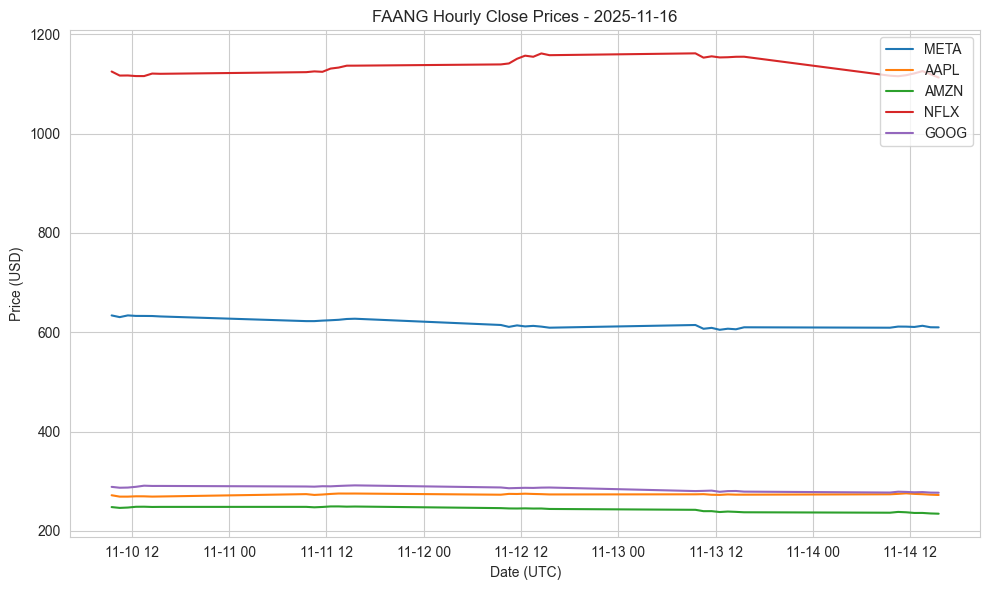

✅ Plot saved: plots\20251116-133857.png


In [11]:
def plot_data():
    tickers = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]
    data = load_latest_data(tickers, folder="data", show_preview=False)

    PLOTS_DIR = Path("plots")
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    for sym, df in data.items():
        if 'Close' in df.columns and not df.empty:
            x = pd.to_datetime(df['Date'], errors='coerce')
            y = df['Close']
            ax.plot(x, y, label=sym)

    today = datetime.now().strftime("%Y-%m-%d")
    ax.set_title(f"FAANG Hourly Close Prices - {today}")
    ax.set_xlabel("Date (UTC)")
    ax.set_ylabel("Price (USD)")
    ax.legend()

    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    filename = PLOTS_DIR / f"{ts}.png"
    fig.tight_layout()
    fig.savefig(filename)
    plt.show()

    print(f"✅ Plot saved: {filename}")

# Call the function
plot_data()


### Interpretation of Close Prices

When the program is run, the plot shows the hourly closing prices for each FAANG stock over the last five days. Each “Close” value represents the price at the end of a one‑hour trading interval, not the single consolidated daily close at market close. 

**This distinction is important:** the daily close may differ from the last hourly close if the market continues to move later in the day. The assignment specifically required hourly data, so the script correctly reflects that requirement, but the title and explanation clarify that these are hourly closes.

### 📊 Optional Steps: Analysis 

#### These plots provide deeper insight but are not part of the formal assessment.

Now that we’ve added the **Return** and **RollingMean** columns in Step 6a, we can use them to create richer visualisations. These plots go beyond simple closing prices and help us understand the behaviour of each FAANG stock in more detail:

- Histograms with KDE overlays of returns
    -   Show how often different return values occur.
    -   The KDE (red curve) smooths the distribution, making it easier to see the overall shape.

- Boxplot comparing return distributions across tickers
    -   Summarises the spread of returns for all FAANG stocks in one chart.
    -   Helps compare volatility between companies.

- Line plots of closing prices with rolling averages
    -   Show the raw closing prices alongside a smoothed 30‑period moving average.
    -   Makes it easier to spot long‑term trends versus short‑term fluctuations.

These visualisations give us both **statistical insight** (returns and volatility) and **trend insight** (rolling averages), making the analysis more complete.

Relevant to: **Problem 2 (Visualisation)** and **Optional Steps: Analysis** — These visualisations also provide deeper insight but are not required by the assessment.

References:

- [pandas.DataFrame.pct_change](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html)
- [pandas.DataFrame.rolling](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html)
- [Seaborn Documentation](https://seaborn.pydata.org/)

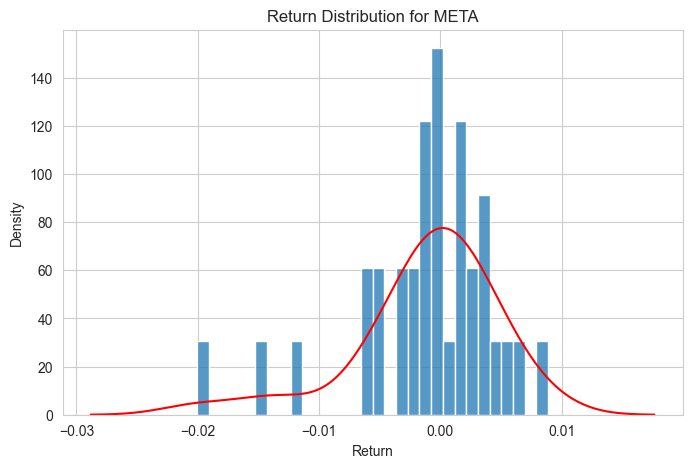

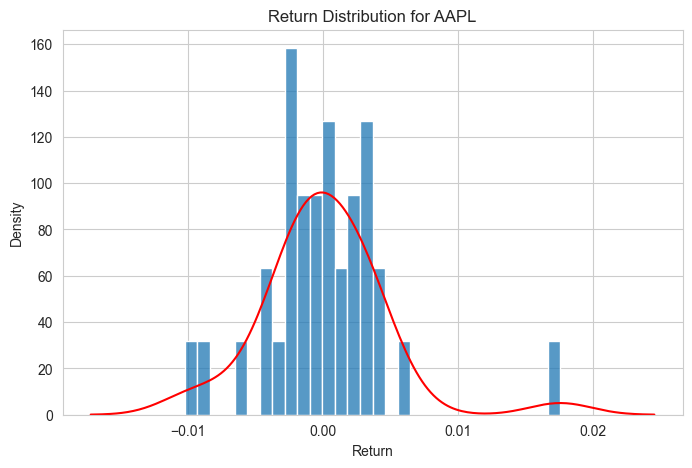

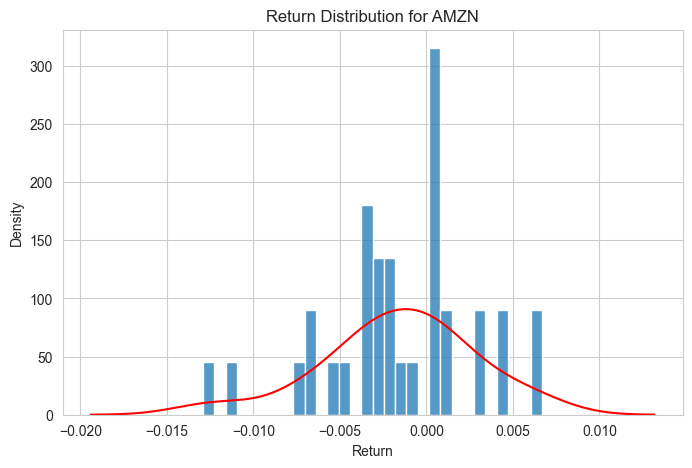

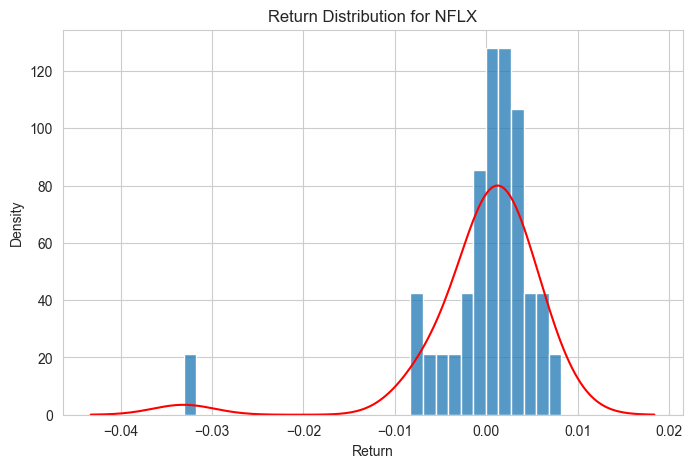

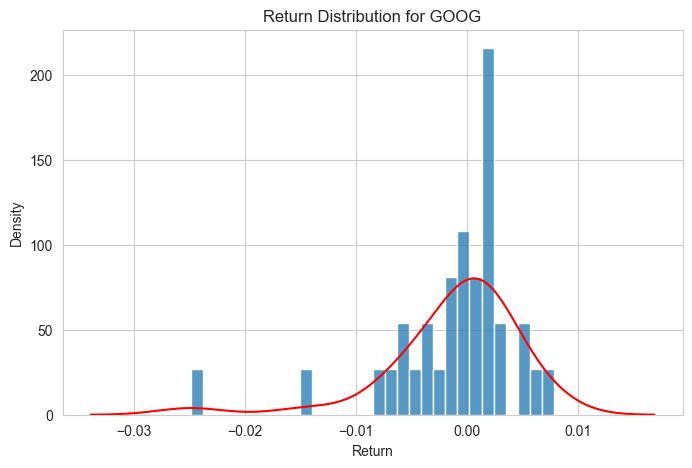

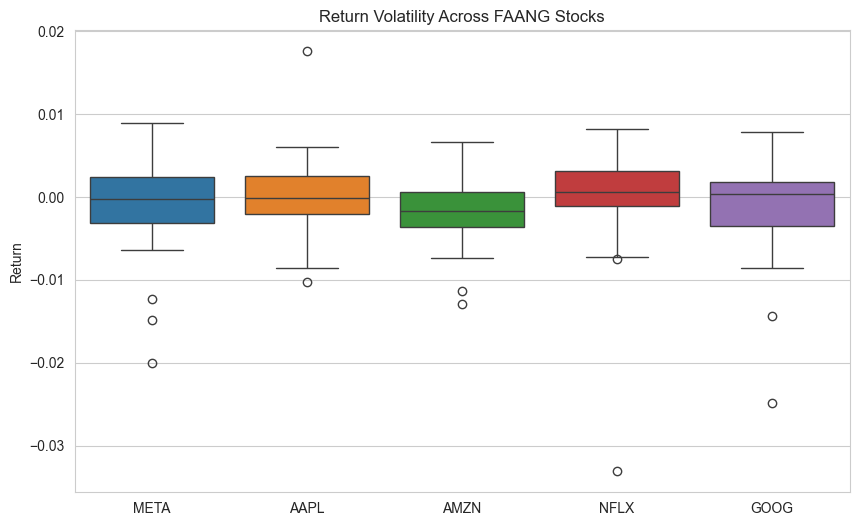

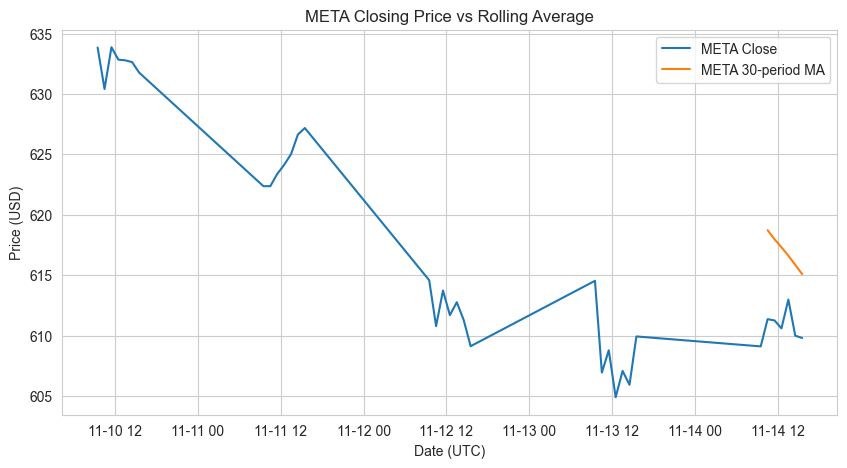

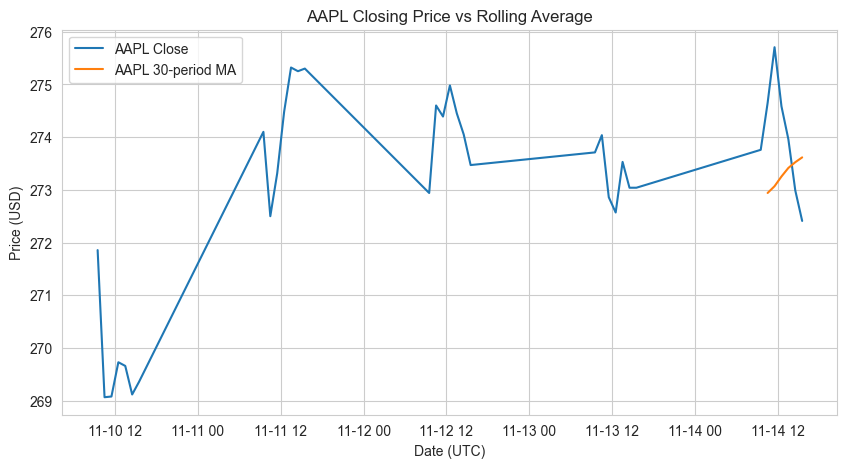

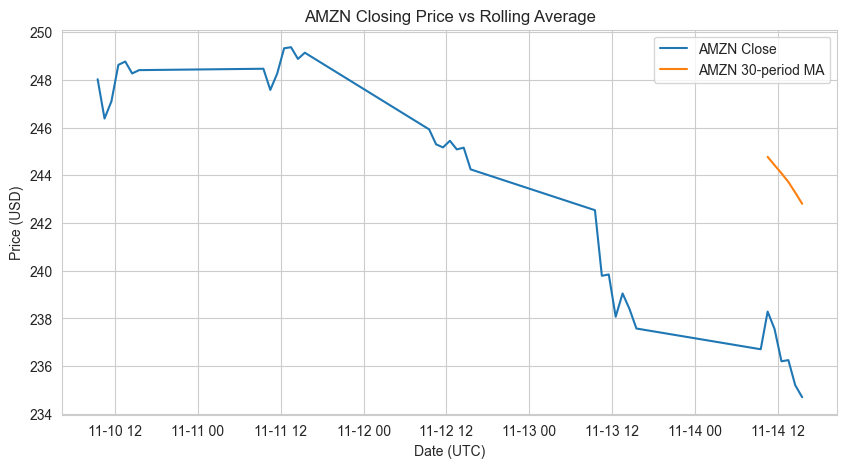

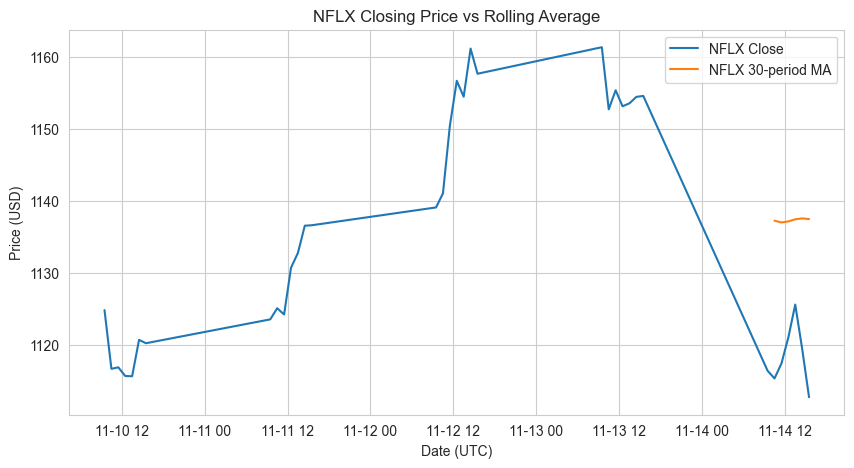

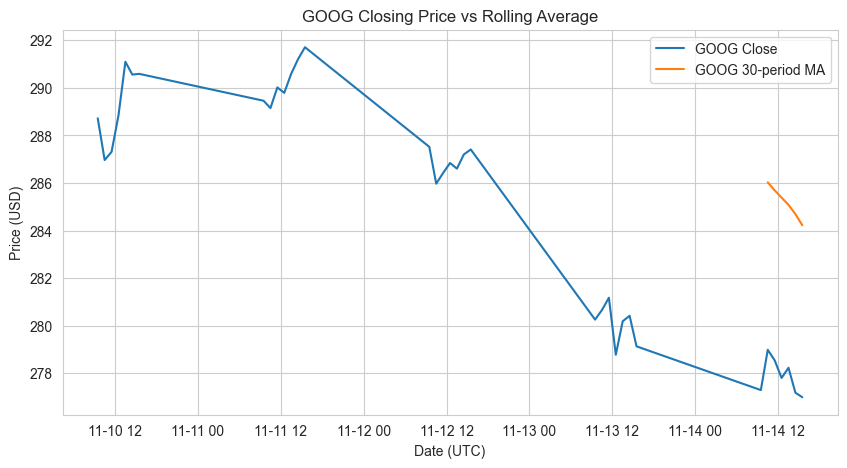

In [12]:
# Step 8 — Histogram + KDE of Returns
for sym, df in data.items():
    # Ensure Return column exists
    if 'Return' not in df.columns:
        df['Return'] = df['Close'].pct_change()

    # Convert to numeric and drop NaN
    returns = pd.to_numeric(df['Return'], errors='coerce').dropna()

    # Plot only if we have valid data
    if not returns.empty:
        plt.figure(figsize=(8, 5))
        # Use the 'x=' parameter to avoid type-checker complaints about positional Series
        sns.histplot(x=returns, bins=30, stat="density")
        sns.kdeplot(x=returns, color="red")
        plt.title(f"Return Distribution for {sym}")
        plt.xlabel("Return")
        plt.ylabel("Density")
        plt.show()
    else:
        print(f"{sym}: ⚠️ No valid returns to plot")


# Boxplot of returns
# Keep using a DataFrame for seaborn.boxplot; align series by resetting index to avoid long alignment NaNs if desired.
returns_df = pd.DataFrame({sym: df['Return'].dropna().reset_index(drop=True) for sym, df in data.items()})
plt.figure(figsize=(10, 6))
sns.boxplot(data=returns_df)
plt.title("Return Volatility Across FAANG Stocks")
plt.ylabel("Return")
plt.show()

# Rolling average plots
for sym, df in data.items():
    # Prefer using the Date column (converted to datetime) for the x-axis
    if 'Date' in df.columns:
        x = pd.to_datetime(df['Date'], errors='coerce')
    else:
        x = pd.to_datetime(df.index, errors='coerce')

    # Ensure RollingMean exists
    if 'RollingMean' in df.columns:
        rm = df['RollingMean']
    else:
        rm = df['Close'].rolling(window=30).mean()

    plt.figure(figsize=(10, 5))
    plt.plot(x, df['Close'], label=f"{sym} Close")
    plt.plot(x, rm, label=f"{sym} 30-period MA")
    plt.title(f"{sym} Closing Price vs Rolling Average")
    plt.xlabel("Date (UTC)")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.show()


### 🔗 Step 9 — Correlation Analysis

In this step, we explore how the FAANG stocks move in relation to each other. To do this, we calculate the correlation between their closing prices:
- A correlation close to **1.0** means two stocks tend to move together.
- A correlation close to **0** means their movements are unrelated.
- A correlation close to **–1.0** means they move in opposite directions.

Here’s what we do:
1. Build a DataFrame where each ticker’s closing prices become a column.
2. Use .corr() to calculate the correlation matrix.
3. Display the matrix as a table (numbers).
4. Plot the matrix as a heatmap (visual), which makes patterns easier to spot.

This analysis helps us understand relationships between FAANG stocks, which is useful for diversification and risk management.

**Optional Steps: Analysis** — This correlation matrix and heatmap explore relationships between FAANG stocks. They are useful for understanding connections but are not required by the assessment.

References:

- [pandas.DataFrame.corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html)
- [Seaborn Heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

📊 Correlation Matrix of FAANG Closing Prices (Missing Values Filled)


,META,AAPL,AMZN,NFLX,GOOG
META,1.000000,-0.180361,0.287097,0.013056,0.083491
AAPL,-0.180361,1.000000,0.024426,0.001111,0.007103
AMZN,0.287097,0.024426,1.000000,0.048860,0.312444
NFLX,0.013056,0.001111,0.048860,1.000000,0.324047
GOOG,0.083491,0.007103,0.312444,0.324047,1.000000


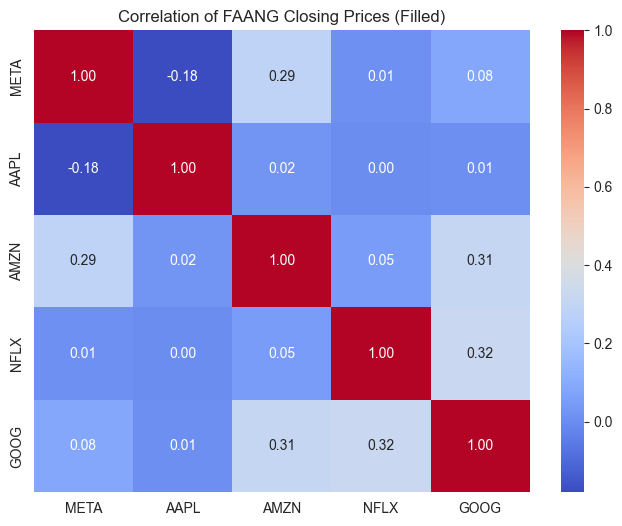

In [13]:
# Step 9 — Correlation Analysis (Fill Missing Values)
# Build DataFrame directly from dictionary: ticker symbols as columns
close_prices = pd.DataFrame({sym: df['Close'] for sym, df in data.items()})

# Fill missing values forward, then backward to ensure no NaNs remain
close_prices = close_prices.ffill().bfill()

# 1. Print correlation matrix table
print("📊 Correlation Matrix of FAANG Closing Prices (Missing Values Filled)")
display(close_prices.corr())

# 2. Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(close_prices.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of FAANG Closing Prices (Filled)")
plt.show()


### 📑 Step 10 — Workflow Documentation  

This notebook demonstrates:  
1. Fetching hourly FAANG data (`get_data`)  
2. Loading and diagnosing datasets (`load_latest_data`)  
3. Previewing, summarising, and validating data  
4. Plotting close prices (`plot_data`)  
5. Extended visualisations (returns, rolling averages, boxplots)  
6. Correlation analysis  
7. Documentation and references  

References:  
- [Pandas User Guide](https://pandas.pydata.org/docs/user_guide/index.html)  
- [Matplotlib Documentation](https://matplotlib.org/stable/contents.html)  
- [Seaborn Documentation](https://seaborn.pydata.org/)  


### Problem 3 – Create a CLI Script (`faang.py`)

To meet the requirements of Problem 3, I created a standalone Python script called `faang.py` in the root of the repository. This script automates the process of downloading hourly stock data for FAANG companies and generating a plot of their closing prices.

Steps taken:
1. **Modularisation**: I copied core functions from the notebook — including `fetch_hourly_history`, `save_hourly_data`, `load_latest_data`, and `plot_close_prices` — into `faang.py` to promote reuse and maintainability.
2. **Shebang Line**: I added `#!/usr/bin/env python3` at the top of the script to make it executable from the terminal.
3. **CLI Interface**: I used the `argparse` module to allow users to control script behavior with flags like `--plot` and `--overwrite`.
4. **Main Execution Block**: I added `if __name__ == "__main__": main()` to ensure the script runs when executed directly.
5. **Executable Permission**: I marked the script as executable using `chmod +x faang.py`.

This implementation allows the script to be run with:
```bash
./faang.py --plot
```

Relevant to: **Problem 3 (Script Creation)**

**Optional analysis steps** from the notebook (such as summary statistics, data quality checks, rolling means, extended visualisations, and correlation analysis) were intentionally excluded from the script to keep it aligned with the assessment guidelines. These remain in the notebook as supplementary exploration only.

References:

- [Assessment Instructions – Computer Infrastructure](https://github.com/ianmcloughlin/computer-infrastructure/blob/main/assessment/problems.md)
- [Python CLI Design with argparse](https://realpython.com/command-line-interfaces-python-argparse/)  
- [Shebang Line Usage](https://realpython.com/python-shebang/)



In [14]:
# 🐍 faang.py — Script Code Cell

#!/usr/bin/env python3
"""
faang.py — Assessment Script for FAANG Stock Analysis — Winter 25/26 Assessment

Author: Edward Cronin

Implements:
- Problem 1: Fetch FAANG hourly data (last 5 days) and save to CSV.
- Problem 2: Plot FAANG hourly closing prices from latest CSV and save to PNG.
- Problem 3: Executable script that runs both steps when called from terminal.

Notes:
- 'Close' refers to the price at the end of each hourly interval, not the final daily close.
- The yfinance API only provides hourly data up to the most recent trading day.
  • On weekdays when markets are open, the script captures hourly closes intraday.
  • On weekends or holidays, no new hourly data is available, so the latest file stops
    at the final close of the last trading session (e.g., Friday’s market close).
- The chart title has been updated to reflect the last available trading date in the dataset,
  ensuring consistency between the plot and the underlying data.
- This aligns with the assignment requirement to fetch 5 days of hourly data.
"""

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
DATA_DIR = Path("data").resolve()
PLOTS_DIR = Path("plots").resolve()
TICKERS = ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']

DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Apply notebook-style aesthetics for consistency
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 12

# --- Helper Functions ---
def fetch_hourly_history(ticker):
    """Fetch hourly FAANG data for the last 5 days."""
    df = yf.Ticker(ticker).history(period='5d', interval='1h')
    if df.empty:
        print(f"⚠️ No data for {ticker}")
        return None
    df['Ticker'] = ticker
    df.index.name = 'Date'
    return df

def save_hourly_data(tickers, output_dir):
    """Save combined FAANG data into data/ folder with timestamped filename."""
    dfs = []
    for t in tickers:
        df = fetch_hourly_history(t)
        if df is not None and not df.empty:
            dfs.append(df)
            print(f"✅ {t}: {len(df)} rows")
        else:
            print(f"⚠️ {t}: No valid data")

    if not dfs:
        print("🚫 No valid data to save.")
        return None

    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"
    final_df.to_csv(path, index_label='Date')
    print(f"✅ Data saved to {path}")
    return str(path)

def load_latest_data(tickers, folder='data'):
    """Load the most recent CSV from data/ folder and split into ticker DataFrames."""
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        print("🚫 No CSV files found.")
        return {}

    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}
    return data

def plot_close_prices(data, output_dir):
    """Plot hourly closing prices for FAANG tickers and save to plots/ folder."""
    fig, ax = plt.subplots()
    plotted = False
    last_date = None

    for sym, df in data.items():
        if 'Close' in df.columns and not df.empty:
            x = pd.to_datetime(df['Date'], errors='coerce')
            y = df['Close']
            ax.plot(x, y, label=sym)
            plotted = True
            # Track the latest date across tickers
            if last_date is None or df['Date'].max() > last_date:
                last_date = df['Date'].max()

    ax.set_xlabel("Date")
    ax.set_ylabel("Close Price (USD)")

    if plotted:
        ax.legend(title="Ticker", loc="best")

    # ✅ Use the last available date from the dataset for the title
    if last_date is not None:
        title_date = pd.to_datetime(last_date).strftime("%Y-%m-%d")
        ax.set_title(f"FAANG Hourly Closing Prices — up to {title_date}")
    else:
        ax.set_title("FAANG Hourly Closing Prices — No Data")

    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    plot_path = output_dir / f"{ts}.png"
    fig.tight_layout()
    fig.savefig(plot_path, bbox_inches='tight')
    plt.close(fig)
    print(f"✅ Plot saved to {plot_path}")

# --- Script Execution ---
def main():
    """Run data download and plotting in sequence (Problems 1–3)."""
    saved_file = save_hourly_data(TICKERS, DATA_DIR)
    if not saved_file:
        print("🚫 No data file saved. Exiting.")
        return
    data = load_latest_data(TICKERS, folder=str(DATA_DIR))
    plot_close_prices(data, PLOTS_DIR)

if __name__ == "__main__":
    main()


✅ META: 35 rows
✅ AAPL: 35 rows
✅ AMZN: 35 rows
✅ NFLX: 35 rows
✅ GOOG: 35 rows
✅ Data saved to C:\Users\eCron\OneDrive\Documents\ATU_CourseWork\computer_infrastructure\data\20251116-133859.csv
✅ Plot saved to C:\Users\eCron\OneDrive\Documents\ATU_CourseWork\computer_infrastructure\plots\20251116-133859.png


### Summary and Transition to Problem 4

With the CLI script `faang.py` now complete, Problem 3 is fully addressed. The script is modular, executable from the terminal, and supports flexible command-line arguments for downloading data and generating plots. It consolidates the notebook’s logic into a reusable tool that can be run manually or integrated into automated workflows.

Next, in **Problem 4**, I will configure a GitHub Actions workflow to run `faang.py` on a schedule. This will automate the data collection and visualization process, ensuring fresh stock data and updated plots are generated regularly without manual intervention.

Relevant to: Problem 4 (Automation)

Reference: [Assessment Instructions – Computer Infrastructure](https://github.com/ianmcloughlin/computer-infrastructure/blob/main/assessment/problems.md)
